# Generation Forecast

In this notebook, ERA-5 actual weather data and ENTSO-E actual generation data are used to build models to explain energy generation for onshore wind, offshore wind, and solar. These models are then used to obtain generation forecasts for these three technologies using NOAA GFS weather forecast data, which are then used as features in the day-ahead price model.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from xgboost import XGBRegressor

import joblib

## Load Generation and ERA-5 Weather Data

In [2]:
# ENTSO-E generation data
gen = pd.read_parquet("ENTSOE/entsoe_generation.parquet")

# ERA5 weather data (already technology-specific aggregations)
base = Path("ERA5/processed")


def load_concat(category: str) -> pd.DataFrame:
    files = sorted((base / category).glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files for {category} were found.")

    df = pd.concat((pd.read_parquet(p) for p in files), ignore_index=False).sort_index()
    return df


df_wind_on = load_concat("wind_on")
df_wind_off = load_concat("wind_off")
df_solar = load_concat("solar")

# change timezone to UTC
df_wind_on.index = df_wind_on.index.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="raise").tz_convert("UTC")
df_wind_off.index = df_wind_off.index.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="raise").tz_convert("UTC")
df_solar.index = df_solar.index.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="raise").tz_convert("UTC")

# one hour too much because of timezone issues in source prep
df_wind_on = df_wind_on.drop(df_wind_on.index[0])
df_wind_off = df_wind_off.drop(df_wind_off.index[0])
df_solar = df_solar.drop(df_solar.index[0])

# combine generation data with weather data
df_wind_on["generation"] = gen["gen_wind_onshore"]
df_wind_off["generation"] = gen["gen_wind_offshore"]
df_solar["generation"] = gen["gen_solar"]

TARGETS = {
    "wind_on": df_wind_on.copy(),
    "wind_off": df_wind_off.copy(),
    "solar": df_solar.copy(),
}

WEATHER_FEATURES = ["ssrd", "tp", "tcc", "t2m", "sp", "U100", "rh2m"]
TARGETS.keys()

dict_keys(['wind_on', 'wind_off', 'solar'])

##  Check Plausibility, Missing Values, Outliers

In [4]:
def target_stats(df: pd.DataFrame) -> pd.Series:
    y = df["generation"]
    q = y.quantile([0.01, 0.99])
    return pd.Series(
        {
            "mean": y.mean(),
            "std": y.std(),
            "p1": q.loc[0.01],
            "p99": q.loc[0.99],
            "min": y.min(),
            "max": y.max(),
        }
    )


stats_table = pd.concat(
    {name: target_stats(df) for name, df in TARGETS.items()}, axis=1
).T
stats_table

,mean,std,p1,p99,min,max
wind_on,11200.195383,9150.656812,608.727650,37789.044125,91.795,43799.255
wind_off,2875.818091,1976.104448,23.086025,6479.105875,0.000,7229.215
solar,5639.713489,8672.863062,0.135000,31842.409600,0.095,38027.990


In [5]:
missing_feature_table = pd.concat(
    {name: df[WEATHER_FEATURES + ["generation"]].isna().sum() for name, df in TARGETS.items()},
    axis=1,
).T
missing_feature_table

,ssrd,tp,tcc,t2m,sp,U100,rh2m,generation
wind_on,0,0,0,0,0,0,0,0
wind_off,0,0,0,0,0,0,0,0
solar,0,0,0,0,0,0,0,0


In [6]:
def detect_outliers_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return (s < lo) | (s > hi)


outlier_share = {}
for name, df in TARGETS.items():
    mask = detect_outliers_iqr(df["generation"].dropna())
    outlier_share[name] = mask.mean() * 100

pd.Series(outlier_share, name="generation_outlier_share_pct").to_frame()

,generation_outlier_share_pct
wind_on,2.566150
wind_off,0.000000
solar,7.595803


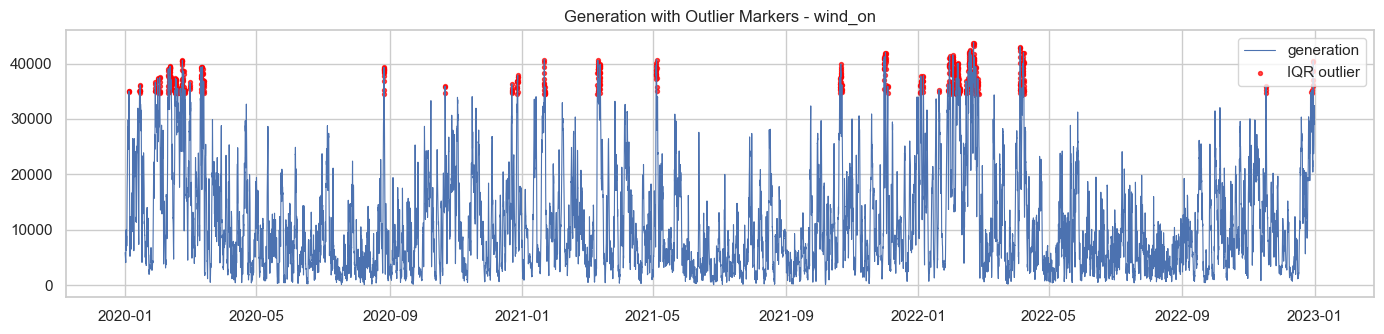

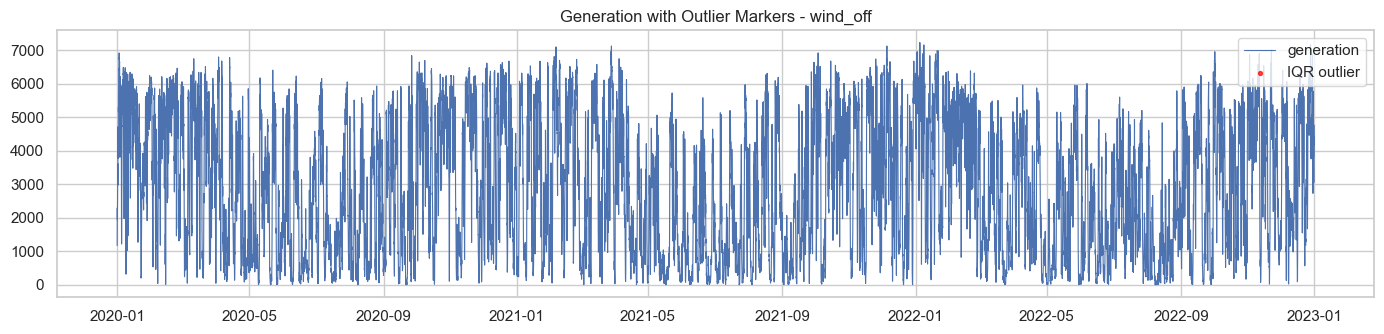

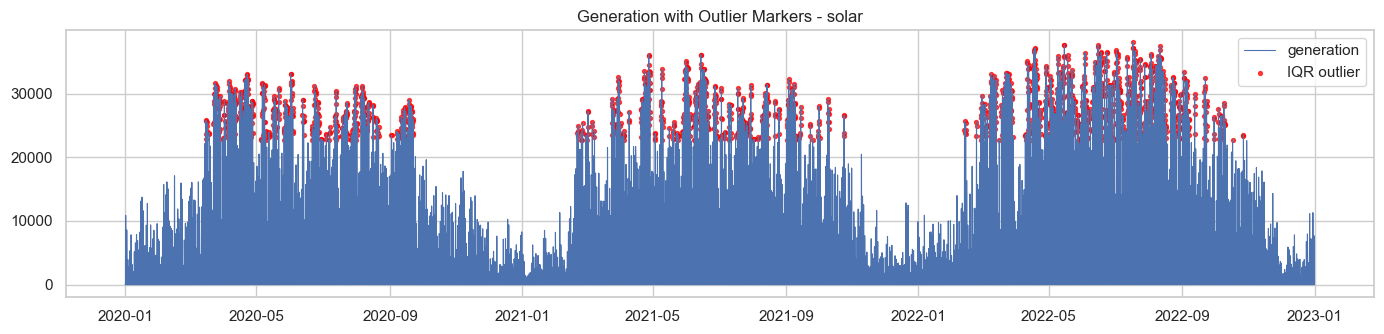

In [6]:
for name, df in TARGETS.items():
    y = df["generation"].copy()
    mask = detect_outliers_iqr(y)

    plt.figure(figsize=(14, 3.5))
    plt.plot(y.index, y.values, linewidth=0.8, label="generation")
    plt.scatter(y.index[mask], y[mask], s=8, color="red", alpha=0.7, label="IQR outlier")
    plt.title(f"Generation with Outlier Markers - {name}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

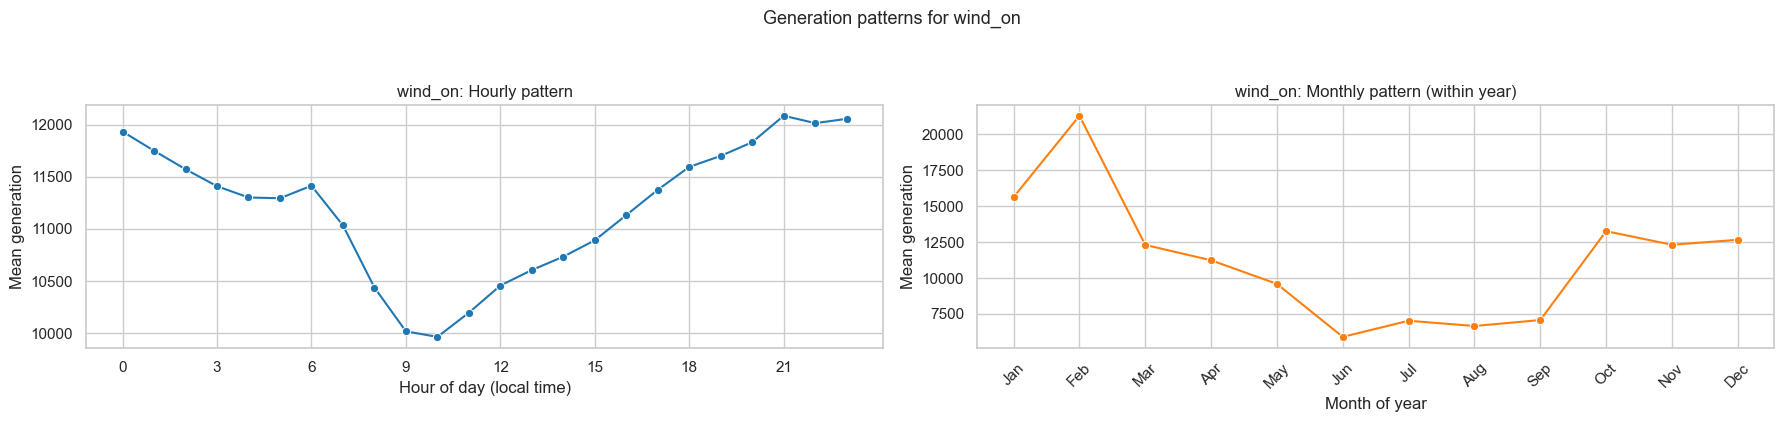

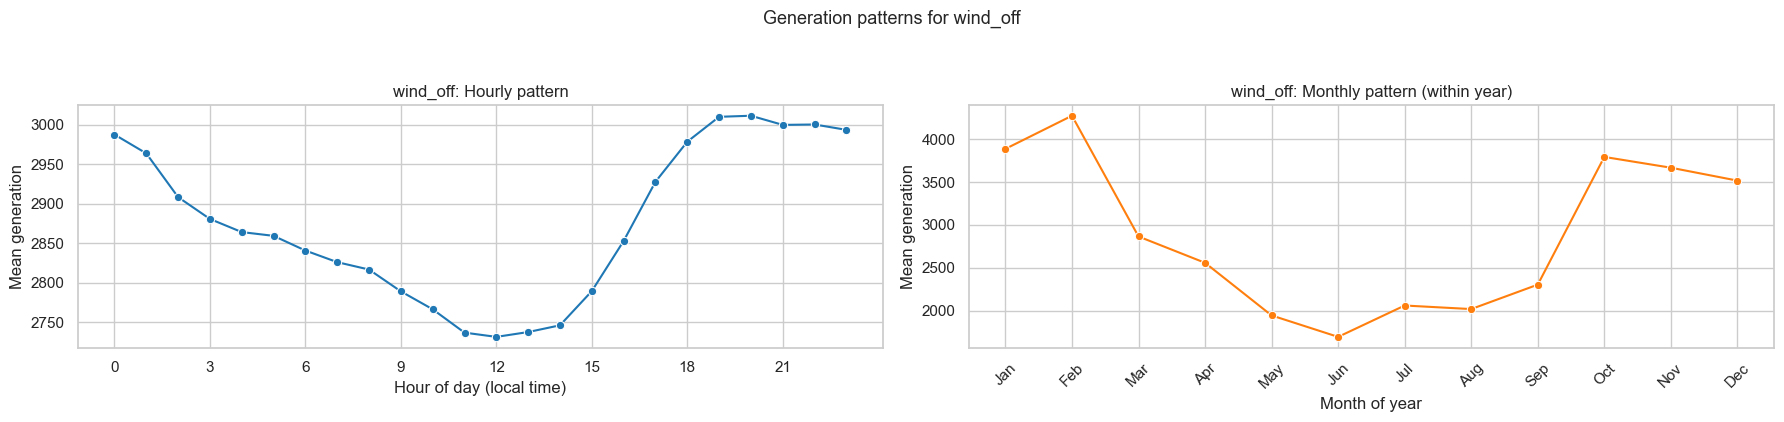

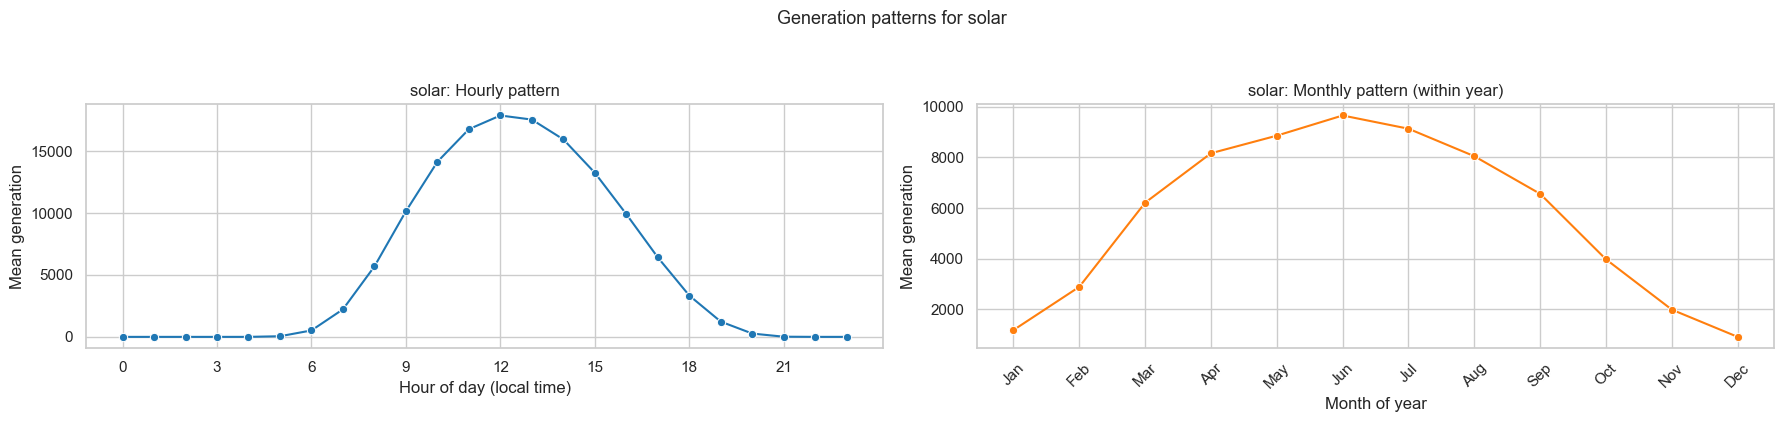

In [3]:
# Seasonal profile diagnostics per technology
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for technology, df in TARGETS.items():
    profile = df[["generation"]].copy().sort_index()
    profile = profile.tz_convert("Europe/Berlin")
    profile["hour"] = profile.index.hour
    profile["month"] = profile.index.month

    hourly_pattern = profile.groupby("hour")["generation"].mean().reindex(range(24))
    monthly_pattern = profile.groupby("month")["generation"].mean().reindex(range(1, 13))

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    sns.lineplot(x=hourly_pattern.index, y=hourly_pattern.values, marker="o", ax=axes[0], color="tab:blue")
    axes[0].set_title(f"{technology}: Hourly pattern")
    axes[0].set_xlabel("Hour of day (local time)")
    axes[0].set_ylabel("Mean generation")
    axes[0].set_xticks(range(0, 24, 3))

    sns.lineplot(x=range(1, 13), y=monthly_pattern.values, marker="o", ax=axes[1], color="tab:orange")
    axes[1].set_title(f"{technology}: Monthly pattern (within year)")
    axes[1].set_xlabel("Month of year")
    axes[1].set_ylabel("Mean generation")
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(month_labels, rotation=45)

    fig.suptitle(f"Generation patterns for {technology}", y=1.05, fontsize=13)
    plt.tight_layout()
    plt.show()


In [4]:
# Add temporal cyclic features from index
TEMPORAL_FEATURES = ["hour_sin", "hour_cos", "month_sin", "month_cos"]

for technology, df in TARGETS.items():
    idx_local = df.index.tz_convert("Europe/Berlin")
    hour = idx_local.hour
    month = idx_local.month

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
    df["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12.0)

# Optional combined feature list for later modeling
ALL_FEATURES = WEATHER_FEATURES + TEMPORAL_FEATURES
TEMPORAL_FEATURES


['hour_sin', 'hour_cos', 'month_sin', 'month_cos']

# Modeling: Year Holdout + TimeSeriesSplit Tuning

- Split: first 2 years for training, last year for final test
- Tuning: TimeSeriesSplit on training period only
- Models per technology: RandomForest and XGBoost


In [5]:
RANDOM_STATE = 1904
CV = TimeSeriesSplit(n_splits=5)
SCORING = "neg_root_mean_squared_error"
N_ITER = 30

TRAIN_TEST_DATA = {}
MODEL_RESULTS = []
BEST_MODELS = {}
MODEL_OBJECTS = {}

RF_PARAM_DISTS = {
    "n_estimators": [100, 200, 300, 400, 500, 600],
    "max_depth": [None, 6, 10, 16, 24],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.7, 1.0],
}

XGB_PARAM_DISTS = {
    "n_estimators": [100, 200, 300, 400, 500, 600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6, 8, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}

def run_random_search_for_technology(technology: str, model_name: str, estimator, param_distributions: dict) -> pd.Series:
    data = TRAIN_TEST_DATA[technology]

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring=SCORING,
        cv=CV,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )

    search.fit(data["X_train"], data["y_train"])
    best_model = search.best_estimator_
    y_pred = best_model.predict(data["X_test"])

    mae = mean_absolute_error(data["y_test"], y_pred)
    rmse = np.sqrt(mean_squared_error(data["y_test"], y_pred))
    r2 = r2_score(data["y_test"], y_pred)

    result = {
        "technology": technology,
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "best_params": search.best_params_,
    }
    MODEL_RESULTS.append(result)
    MODEL_OBJECTS[(technology, model_name)] = best_model

    return pd.Series(result)


In [25]:
# Data checks and explicit 2-year train / 1-year test split
split_summary_rows = []

for technology, df in TARGETS.items():
    data = df[ALL_FEATURES + ["generation"]].copy().sort_index()

    years = sorted(data.index.year.unique().tolist())
    if len(years) != 3:
        raise ValueError(f"{technology}: expected exactly 3 years, found {years}")

    train_years = years[:2]
    test_year = years[2]

    train_df = data[data.index.year.isin(train_years)]
    test_df = data[data.index.year == test_year]

    TRAIN_TEST_DATA[technology] = {
        "train_years": train_years,
        "test_year": test_year,
        "X_train": train_df[ALL_FEATURES].copy(),
        "y_train": train_df["generation"].copy(),
        "X_test": test_df[ALL_FEATURES].copy(),
        "y_test": test_df["generation"].copy(),
    }

    split_summary_rows.append({
        "technology": technology,
        "train_years": f"{train_years[0]}-{train_years[1]}",
        "test_year": test_year,
        "train_start": train_df.index.min(),
        "train_end": train_df.index.max(),
        "test_start": test_df.index.min(),
        "test_end": test_df.index.max(),
        "n_train": len(train_df),
        "n_test": len(test_df),
    })

split_summary = pd.DataFrame(split_summary_rows).set_index("technology")
split_summary


,train_years,test_year,train_start,train_end,test_start,test_end,n_train,n_test
technology,,,,,,,,
wind_on,2020-2021,2022,2020-01-01 00:00:00+00:00,2021-12-31 23:00:00+00:00,2022-01-01 00:00:00+00:00,2022-12-31 23:00:00+00:00,17544,8760
wind_off,2020-2021,2022,2020-01-01 00:00:00+00:00,2021-12-31 23:00:00+00:00,2022-01-01 00:00:00+00:00,2022-12-31 23:00:00+00:00,17544,8760
solar,2020-2021,2022,2020-01-01 00:00:00+00:00,2021-12-31 23:00:00+00:00,2022-01-01 00:00:00+00:00,2022-12-31 23:00:00+00:00,17544,8760


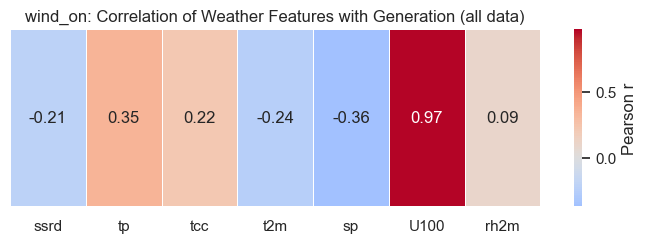

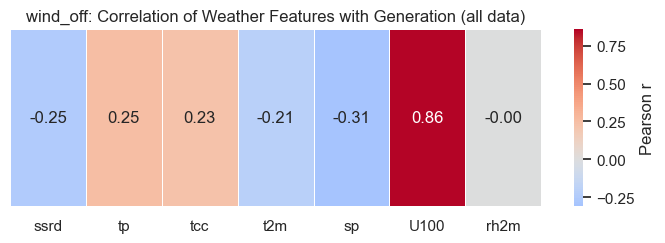

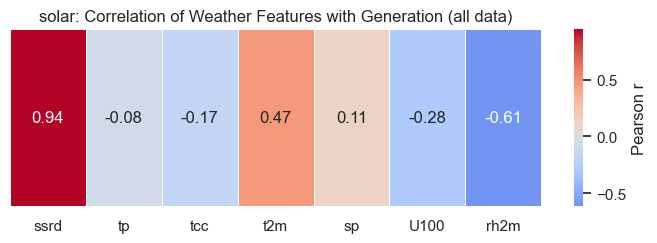

In [19]:
# Correlation diagnostics on train data
for technology, data in TRAIN_TEST_DATA.items():
    X_all = pd.concat([data["X_train"], data["X_test"]], axis=0).sort_index()
    y_all = pd.concat([data["y_train"], data["y_test"]], axis=0).sort_index()

    corr_series = (
        pd.concat([X_all, y_all], axis=1)
        .corr(numeric_only=True)["generation"]
        .drop("generation")
    )

    plt.figure(figsize=(7, 2.6))
    sns.heatmap(
        corr_series.to_frame().T,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Pearson r"},
    )
    plt.title(f"{technology}: Correlation of Weather Features with Generation (all data)")
    plt.yticks([])
    plt.tight_layout()
    plt.show()


# Train + Hyperparameter Tuning: RandomForest and XGBoost per technology


In [7]:
# wind_on | RandomForest
rf_wind_on = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
run_random_search_for_technology("wind_on", "RandomForest", rf_wind_on, RF_PARAM_DISTS)


technology                                               wind_on
model                                               RandomForest
mae                                                  1175.353397
rmse                                                 1654.465813
r2                                                      0.970453
best_params    {'n_estimators': 200, 'min_samples_split': 20,...
dtype: object

In [8]:
# wind_on | XGBoost
xgb_wind_on = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
run_random_search_for_technology("wind_on", "XGBoost", xgb_wind_on, XGB_PARAM_DISTS)


technology                                               wind_on
model                                                    XGBoost
mae                                                  1182.015097
rmse                                                 1664.710857
r2                                                      0.970086
best_params    {'subsample': 1.0, 'reg_lambda': 10, 'reg_alph...
dtype: object

In [9]:
# wind_off | RandomForest
rf_wind_off = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
run_random_search_for_technology("wind_off", "RandomForest", rf_wind_off, RF_PARAM_DISTS)


technology                                              wind_off
model                                               RandomForest
mae                                                   468.102529
rmse                                                  643.775502
r2                                                      0.884154
best_params    {'n_estimators': 600, 'min_samples_split': 2, ...
dtype: object

In [10]:
# wind_off | XGBoost
xgb_wind_off = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
run_random_search_for_technology("wind_off", "XGBoost", xgb_wind_off, XGB_PARAM_DISTS)


technology                                              wind_off
model                                                    XGBoost
mae                                                   467.893756
rmse                                                  644.153004
r2                                                      0.884018
best_params    {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha...
dtype: object

In [26]:
# solar | RandomForest
rf_solar = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
run_random_search_for_technology("solar", "RandomForest", rf_solar, RF_PARAM_DISTS)


technology                                                 solar
model                                               RandomForest
mae                                                   928.514242
rmse                                                  1806.16034
r2                                                      0.965446
best_params    {'n_estimators': 300, 'min_samples_split': 2, ...
dtype: object

In [27]:
# solar | XGBoost
xgb_solar = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
run_random_search_for_technology("solar", "XGBoost", xgb_solar, XGB_PARAM_DISTS)


technology                                                 solar
model                                                    XGBoost
mae                                                   950.493673
rmse                                                 1841.858184
r2                                                      0.964066
best_params    {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha...
dtype: object

In [28]:
# Results comparison and winner selection per technology
results_df = pd.DataFrame(MODEL_RESULTS)

mean_generation_by_tech = {
    technology: split_data["y_test"].mean()
    for technology, split_data in TRAIN_TEST_DATA.items()
}
results_df["mean_generation"] = results_df["technology"].map(mean_generation_by_tech)
results_df["mae_over_mean_generation"] = results_df["mae"] / results_df["mean_generation"]

display(
    results_df[[
        "technology",
        "model",
        "mean_generation",
        "mae",
        "mae_over_mean_generation",
        "rmse",
        "r2",
        "best_params",
    ]].sort_values(["technology", "rmse", "mae"])
)

winner_rows = (
    results_df.sort_values(["technology", "rmse", "mae"])
    .groupby("technology", as_index=False)
    .first()
)

BEST_MODELS = {
    row["technology"]: {
        "model_name": row["model"],
        "estimator": MODEL_OBJECTS[(row["technology"], row["model"])],
        "metrics": {
            "mean_generation": row["mean_generation"],
            "mae": row["mae"],
            "mae_over_mean_generation": row["mae_over_mean_generation"],
            "rmse": row["rmse"],
            "r2": row["r2"],
        },
    }
    for _, row in winner_rows.iterrows()
}

winner_rows[[
    "technology",
    "model",
    "mean_generation",
    "mae",
    "mae_over_mean_generation",
    "rmse",
    "r2",
]].sort_values("technology")


,technology,model,mean_generation,mae,mae_over_mean_generation,rmse,r2,best_params
2,solar,RandomForest,6391.267751,928.514242,0.145279,1806.160340,0.965446,"{'n_estimators': 300, 'min_samples_split': 2, ..."
3,solar,XGBoost,6391.267751,950.493673,0.148718,1841.858184,0.964066,"{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha..."
0,solar,RandomForest,6391.267751,1443.703308,0.225887,2738.316782,0.920575,"{'n_estimators': 300, 'min_samples_split': 2, ..."
1,solar,XGBoost,6391.267751,1457.522503,0.228049,2747.713353,0.920029,"{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha..."


,technology,model,mean_generation,mae,mae_over_mean_generation,rmse,r2
0,solar,RandomForest,6391.267751,928.514242,0.145279,1806.16034,0.965446


### Save models

In [ ]:
models_dir = Path("models") / "generation_forecast"
models_dir.mkdir(parents=True, exist_ok=True)

saved_files = {}
for technology, payload in BEST_MODELS.items():
    model_name = payload["model_name"]
    estimator = payload["estimator"]
    out_path = models_dir / f"best_{technology}_{model_name}.joblib"
    joblib.dump(estimator, out_path)
    saved_files[technology] = out_path
    print(f"Saved {technology}: {out_path}")

Saved solar: models/generation_forecast/best_solar_RandomForest.joblib
Saved wind_off: models/generation_forecast/best_wind_off_RandomForest.joblib
Saved wind_on: models/generation_forecast/best_wind_on_RandomForest.joblib


['solar', 'wind_off', 'wind_on']

# Build Generation Forecast

In [17]:
# load weather forecast data

base = Path("NOAA GFS/processed")

def load_daily(category: str) -> pd.DataFrame:
    files = sorted([p for p in (base / category).glob("*.parquet") if len(p.stem) == 8])
    return pd.concat([pd.read_parquet(p) for p in files]).sort_index()

fc_wind_on = load_daily("wind_on")
fc_wind_off = load_daily("wind_off")
fc_solar = load_daily("solar")

print("Data loaded:")
print(" - wind_on:", fc_wind_on.shape)
print(" - wind_off:", fc_wind_off.shape)
print(" - solar:", fc_solar.shape)

Data loaded:
 - wind_on: (26399, 7)
 - wind_off: (26399, 7)
 - solar: (26351, 7)


In [18]:
# load generation models
models_dir = Path("models") / "generation_forecast"
model_files = sorted(models_dir.glob("best_*.joblib"))
if not model_files:
    raise FileNotFoundError("No saved models found in models/generation_forecast.")

loaded_models = {}
for model_path in model_files:
    stem = model_path.stem
    if stem.startswith("best_wind_on_"):
        technology = "wind_on"
    elif stem.startswith("best_wind_off_"):
        technology = "wind_off"
    elif stem.startswith("best_solar_"):
        technology = "solar"
    else:
        continue
    loaded_models[technology] = joblib.load(model_path)

dfs_by_technology = {
    "wind_on": fc_wind_on,
    "wind_off": fc_wind_off,
    "solar": fc_solar,
}


# calculate forecasts
for technology, model in loaded_models.items():
    df_target = dfs_by_technology[technology]

    X_pred = df_target[WEATHER_FEATURES].copy()
    valid_mask = X_pred.notna().all(axis=1)

    forecast = pd.Series(index=df_target.index, dtype="float64")
    forecast.loc[valid_mask] = model.predict(X_pred.loc[valid_mask])
    df_target["generation_forecast"] = forecast

### Save forecasts

In [22]:
# Save only generation_forecast columns as parquet (one file per technology)
out_dir = Path("generation_forecast")
out_dir.mkdir(parents=True, exist_ok=True)


for technology, df_fc in dfs_by_technology.items():
    if "generation_forecast" not in df_fc.columns:
        raise ValueError(f"{xtechnology}: 'generation_forecast' column not found. Run the forecast cell first.")

    out_path = out_dir / f"{technology}_generation_forecast.parquet"
    df_fc[["generation_forecast"]].to_parquet(out_path, index=True)
    print(f"Saved: {out_path}")

Saved: generation_forecast/wind_on_generation_forecast.parquet
Saved: generation_forecast/wind_off_generation_forecast.parquet
Saved: generation_forecast/solar_generation_forecast.parquet
